In [1]:
from resources.imports import *
from fractions import Fraction
from ipywidgets import interact, FloatSlider

# Latin Hypercube Sampling (LHS)

In [2]:
def LHS_uniform(var, strats, lim, mean=0, plot=False):
    lower_limits = np.linspace(mean-lim, mean+lim, strats, endpoint=False)
    upper_limits = lower_limits + ((lower_limits[-1] - lower_limits[0])/(len(lower_limits)-1))
    
    points = np.zeros((strats, var))
    for i in range(var):
        points[:, i] = np.random.uniform(lower_limits, upper_limits, size=strats)
        np.random.shuffle(points[:, i])
    if plot:
        plot_LHS(points, lim, np.append(lower_limits, upper_limits))
    return points

def LHS_scipy(var, strats, lim, opt=None, plot=False):
    sampler = scipy.stats.qmc.LatinHypercube(d=var, optimization=opt)
    points = sampler.random(n=strats)
    discrepancy = scipy.stats.qmc.discrepancy(points)
    points = scipy.stats.qmc.scale(points, -0.2, 0.2)
    if plot:
        plot_LHS(points, lim, np.linspace(-lim, lim, len(points[:,0])+1))
    return points, discrepancy, sampler

def plot_LHS(p, lim, ticks, dims=[0, 1]):
    plt.figure(figsize=(6, 6))
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.xlabel("$\Delta x_i$")
    plt.ylabel("$\Delta y_i$")
    plt.scatter(p[:, dims[0]], p[:, dims[1]], c="r")
    plt.grid()
    plt.show()

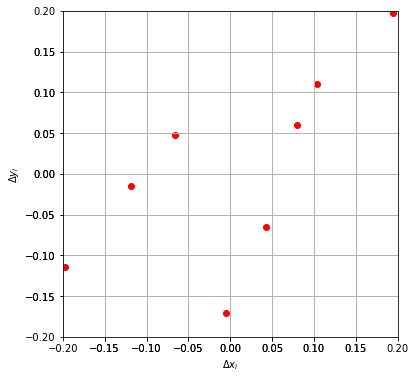

In [3]:
points = LHS_uniform(var=4, strats=8, lim=0.2, plot=True)

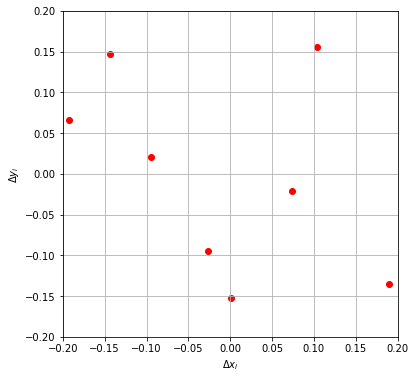

In [4]:
points, discrepency, sampler = LHS_scipy(var=4, strats=8, lim=0.2, plot=True)

[-0.1  0.   0.1  0.2] [-0.2 -0.1  0.   0.1]


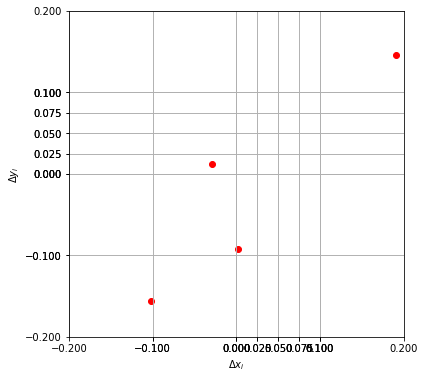

array([[-0.02917344,  0.01260697,  0.19626758,  0.12800075],
       [ 0.00211244, -0.09189047,  0.05188575,  0.07058867],
       [ 0.19038634,  0.14532561, -0.16536252, -0.01083041],
       [-0.10186971, -0.15639052, -0.00763499, -0.14547829]])

In [5]:
def LHS_refined(vars, strats, lim, mean=0, plot=False, refined=False):
    lower_limits = np.linspace(mean-lim, mean+lim, strats, endpoint=False)
    upper_limits = lower_limits + (lower_limits[1] - lower_limits[0])
    
    xticks, yticks = np.append(lower_limits, upper_limits), np.append(lower_limits, upper_limits)

    if refined:

        for i, lims in enumerate(refined):
            lower_limits_ = np.linspace(lims[0], lims[1], strats, endpoint=False)
            upper_limits_ = lower_limits_ + (lower_limits_[1] - lower_limits_[0])

            ticks_ = np.append(lower_limits_, upper_limits_)
            if i == 0:
                xticks = np.append(xticks, ticks_)
            elif i == 1:
                yticks = np.append(yticks, ticks_)
    ticks = np.array([xticks, yticks])
    
    print(upper_limits, lower_limits)

    points = np.zeros((strats, vars))
    for i in range(vars):
        points[:, i] = np.random.uniform(lower_limits, upper_limits, size=strats)
        np.random.shuffle(points[:, i])
    
    if plot:
        plot_LHS(points, lim, ticks[0])

    return points

LHS_refined(vars=4, strats=4, lim=0.2, plot=True, refined=[[0, 0.1], [-0.1, 0]])

# Markov-Chain Monte Carlo (MCMC)

# Frequency Function

Chosen frequencies: [0.035456497956787396, 0.03050415321768656, 0.022602549891006046, 0.02193656388841197, 0.04258050382951492, 0.0009358551422157413, 0.033822751118338504, 0.024319048919971914, 0.0038399499066463063, 0.029743111211567544, 0.035864094866509946, 0.016332497543203685, 0.04241892359490376, 0.023015780166621702, 0.011132024158964866, 0.027714259683103912, 0.03693284013647194, 0.007286457984211287, 0.04027868852926844, 0.045035585171633856, 0.008280284768153746, 0.04933433485553004, 0.0392868815017882, 0.020977872958949335, 0.036497243919466314, 0.02784630290398958, 0.004898926960812406, 0.023057538770826683, 0.0357330119767763, 0.03295265359143151, 0.03655702031081512, 0.007149335317911721, 0.013610894228942289, 0.0073506113592903995, 0.041567811575687605, 0.04496547442986821, 0.04070854176700445, 0.03279910707232171, 0.0424077020123832, 0.044615214216770435, 0.04875065775343304, 0.04917097497020891, 0.033336496285009856, 0.036560236006957916, 0.04271833013578702, 0.014330

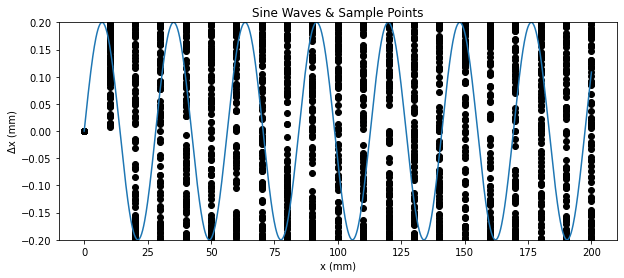

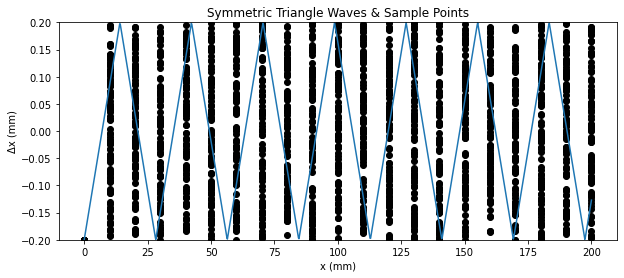

In [6]:
A = 0.2         # amplitude (mm)
length = 200    # total length (mm)
num = 1000      # number of continuous plot points
dx_sample = 10  # sampling interval (mm)

x_cont = np.linspace(0, length, num)
x_samp = np.arange(0, length + dx_sample, dx_sample)


def triangle_wave(x, f, A):
    frac = np.mod(f * x, 1.0)
    tri = np.where(frac < 0.5, 2 * frac, 2 * (1 - frac))
    return A * (2 * tri - 1)

def sine_wave(x, f, A):
    return A * np.sin(2 * np.pi * f * x)

def is_well_approximable(alpha, q_max=20, tol=1e-6):
    """
    Check if alpha is within 'tol' of some p/q with q <= q_max.
    Returns True if alpha is too close to such a rational.
    """
    frac = Fraction(alpha).limit_denominator(q_max)
    return abs(alpha - frac.numerator/frac.denominator) < tol

def random_low_alias_freq(dx=10.0, q_max=20, tol=1e-6):
    """
    Randomly pick a frequency f in (0, 1/(2*dx)) such that f*dx
    is not too well approximable by any p/q with q <= q_max.
    
    Parameters
    ----------
    dx : float
        Sampling interval (e.g. 10.0 mm).
    q_max : int
        Maximum denominator to check for rational approximations.
    tol : float
        Tolerance for how “close” to a rational is considered bad.
    
    Returns
    -------
    float
        A frequency f (cycles per unit length) suitable for sampling.
    """
    f_max = 1.0 / (2.0 * dx)
    while True:
        f = random.uniform(0, f_max)
        alpha = f * dx
        if not is_well_approximable(alpha, q_max=q_max, tol=tol):
            return f

frequencies = []
while len(frequencies) < 100:
    f = random_low_alias_freq(dx=dx_sample)
    if f not in frequencies:  # Ensure unique frequencies
        frequencies.append(f)
print(f"Chosen frequencies: {frequencies}")

plt.figure(figsize=(10, 4))
plt.plot(x_cont, sine_wave(x_cont, frequencies[0], A), label=f"f={frequencies[0]}")
for f in frequencies:
    plt.scatter(x_samp, sine_wave(x_samp, f, A), color='k')
    # print(f, "---", sine_wave(x_samp, f, A))
plt.title("Sine Waves & Sample Points")
plt.ylim(-A, A); plt.xlabel("x (mm)"); plt.ylabel("Δx (mm)"); #plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x_cont, triangle_wave(x_cont, frequencies[0], A), label=f"f={frequencies[0]}")
for f in frequencies:
    plt.scatter(x_samp, triangle_wave(x_samp, f, A), color='k')
    # print(f, "---", triangle_wave(x_samp, f, A))
plt.title("Symmetric Triangle Waves & Sample Points")
plt.ylim(-A, A); plt.xlabel("x (mm)"); plt.ylabel("Δx (mm)"); #plt.legend()
plt.show()

def plot_waves(f=0.01):
    x_cont = np.linspace(0, length, num)
    x_samp = np.arange(0, length + dx_sample, dx_sample)

    # Sine
    plt.figure(figsize=(10, 3))
    plt.plot(x_cont, sine_wave(x_cont, f, A))
    plt.scatter(x_samp, sine_wave(x_samp, f, A), color='k')
    plt.title(f"Sine Wave — f={f:.4f} cyc/mm, sampled every {dx_sample} mm")
    plt.ylim(-A, A); plt.xlabel("x (mm)"); plt.ylabel("Δx (mm)")
    plt.show()

    print(A * np.sin(2 * np.pi * f * x_samp))

    # Triangle
    plt.figure(figsize=(10, 3))
    plt.plot(x_cont, triangle_wave(x_cont, f, A))
    plt.scatter(x_samp, triangle_wave(x_samp, f, A), color='k')
    plt.title(f"Triangle Wave — f={f:.4f} cyc/mm, sampled every {dx_sample} mm")
    plt.ylim(-A, A); plt.xlabel("x (mm)"); plt.ylabel("Δx (mm)")
    plt.show()

    print(A * triangle_wave(x_samp, f, A))

# slider = FloatSlider(value=0.01, min=0.001, max=0.1, step=0.001, description='Frequency')
# interact(plot_waves, f=slider)
